In [18]:
import arviz as az
import jax.numpy as jnp
import pandas as pd

from cppp.load import load_multisensory_data
from cppp.models import multisensory

# participant = 177196795
participant = 135033060
# participant = 182095555
prop_delay = 1
vis_delay = 2
seed = 3
nwarmup = 2500
nsamp = 2500
nchain = 4
model_class_name = "BoundedActorPointMassDynamics"
conditions = "['prop', 'vis', 'multi']"

# load the inference data for all models
models = {
    model_name: az.from_netcdf(
        f"../results/multisensory_fits/multisensory-mcmc-{participant}_{prop_delay}_{vis_delay}_{seed}_{nwarmup}_{nsamp}_{nchain}_{model_name}_{model_class_name}_{conditions}.nc"
    )
    for model_name in ["optimal", "no_integration"]
}

In [19]:

df = load_multisensory_data(base_path="../data")

print(df["participant"].unique())

df = df[df["participant"] == participant]

Multisensory DataFrame loaded from ../data/multisensory/data_all_downsampled.csv with shape: (540746, 12)
[135033060 173058413 177196795 182095555 212056115 330954011 524048600
 544725341 644801403 657093471 714671738 741917610 765738475 799755310
 802096684 879521247 891444214 910949717 918338248]


In [20]:
from simulate_multisensory import get_model

In [26]:
import numpy as np
from jax import jit, vmap, random
from jax.scipy.special import logsumexp
from functools import partial

model_class = getattr(multisensory, "Bias" + model_class_name)

dt = 0.075

likelihood_df = []
dfs = []
delays = {"prop": prop_delay, "vis": vis_delay}
for k, (model_name, model_fit) in enumerate(models.items()):
    print(f"Evaluating model: {model_name}")

    # extract posterior samples into dict
    samples = {
        k: model_fit.posterior[k].values.flatten()
        for k in ["action_variability", "action_cost", "sigma_prop"]
    }
    samples.update(
        {
            f"sigma_vis[{i}]": model_fit.posterior["sigma_vis"].values[..., i].flatten()
            for i in range(2)
        }
    )

    # get 1000 random samples from the posterior
    samples = {k: v[np.random.choice(v.shape[0], size=100)] for k, v in samples.items()}
    print(
        f"Posterior samples for {model_name}: { {k: v.shape for k, v in samples.items()} }"
    )

    @partial(jit, static_argnums=(1,))
    def log_likelihood_fn(x, vis_noise, params, offset):

        model, delay_list = get_model(
            vis_noise=vis_noise,
            model_name=model_name,
            params=params,
            delays=delays,
            dt=dt,
            model_class=model_class,
            T=x.shape[0] - 1,
            knows_about_bias=False
        )
        if model_class == multisensory.BiasBoundedActorPointMassDynamics:
            x0 = jnp.array([x[0, 0], x[0, 1], 0.0, 0.0, offset] * (max(delay_list) + 1))
            xhat0 = jnp.array([x[0, 0], x[0, 1], 0.0, 0.0] * (max(delay_list) + 1))

        elif model_class == multisensory.BiasBoundedActor:
            x0 = jnp.array([x[0, 0], x[0, 1], offset] * (max(delay_list) + 1))
            xhat0 = jnp.array([x[0, 0], x[0, 1]] * (max(delay_list) + 1))

        return model.log_likelihood(x[None], x0=x0[None], xhat0=xhat0[None])

    @partial(jit, static_argnums=(1,))
    def simulate_calibration_phase(
        bias,
        vis_noise,
        params,
        key,
    ):
        model, delay_list = get_model(
            vis_noise=vis_noise,
            model_name=model_name,
            params=params,
            delays=delays,
            dt=dt,
            model_class=model_class,
            T=168,
            knows_about_bias=False,
        )

        if model_class == multisensory.BiasBoundedActorPointMassDynamics:
            x0 = jnp.array([0.0, 0.0, 0.0, 0.0, bias] * (max(delay_list) + 1))
        elif model_class == multisensory.BiasBoundedActor:
            x0 = jnp.array([0.0, 0.0, bias] * (max(delay_list) + 1))
        x = model.simulate(
            rng_key=key,
            n=1,
            x0=x0,
            xhat0=jnp.zeros(model.bdim),
        )
        return x[0]

    for (trial_number, vis_noise), trial_df in df[df["phase"] == "calibration"].groupby(
        ["trial_number", "vis_noise"]
    ):
        offset = trial_df["cursor_offset"].iloc[0]
        print(offset)
        x = jnp.stack(
            [trial_df["cursory_pos"].to_numpy(), trial_df["lefty_pos"].to_numpy()]
        ).T

        x = x[12:]

        x_sim = vmap(
            lambda params, key: simulate_calibration_phase(
                bias=offset, vis_noise=vis_noise, params=params, key=key
            )
        )(samples, random.split(random.PRNGKey(0), 100))

        for rep, x_i in enumerate(x_sim):
            dfs.append(
                pd.DataFrame(
                    {
                        "participant": participant,
                        "phase": "calibration",
                        "cursor_offset": offset,
                        "vis_noise": vis_noise,
                        "trial_number": trial_number,
                        "model": model_name,
                        "model_class": model_class_name,
                        "righty_pos": x_i[:, 0],
                        "lefty_pos": x_i[:, 1],
                        "repetition": rep,
                        "time": np.arange(x_i.shape[0]) * dt,
                    }
                )
            )

        ll = vmap(lambda params: log_likelihood_fn(x, vis_noise, params, offset))(
            samples
        )

        likelihood_df.append(
            {
                "model": model_name,
                "vis_noise": vis_noise,
                "trial_number": trial_number,
                "log_likelihood": (logsumexp(ll) - jnp.log(ll.shape[0])).item(),
            }
        )

Evaluating model: optimal
Posterior samples for optimal: {'action_variability': (100,), 'action_cost': (100,), 'sigma_prop': (100,), 'sigma_vis[0]': (100,), 'sigma_vis[1]': (100,)}
0.5
0.5
1.0
1.0
1.5
1.5
2.0
2.0
2.5
2.5
3.0
3.0
3.5
3.5
4.0
4.0
4.5
4.5
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
Evaluating model: no_integration
Posterior samples for no_integration: {'action_variability': (100,), 'action_cost': (100,), 'sigma_prop': (100,), 'sigma_vis[0]': (100,), 'sigma_vis[1]': (100,)}
0.5
0.5
1.0
1.0
1.5
1.5
2.0
2.0
2.5
2.5
3.0
3.0
3.5
3.5
4.0
4.0
4.5
4.5
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0
5.0


In [27]:

likelihood_df = pd.DataFrame(likelihood_df)



In [28]:
likelihood_df["log_likelihood"]

0     -392.871521
1     -232.286255
2     -293.949799
3     -225.849518
4     -256.126709
          ...    
99    -373.636261
100   -303.926392
101   -267.977386
102   -378.980682
103   -374.214905
Name: log_likelihood, Length: 104, dtype: float64

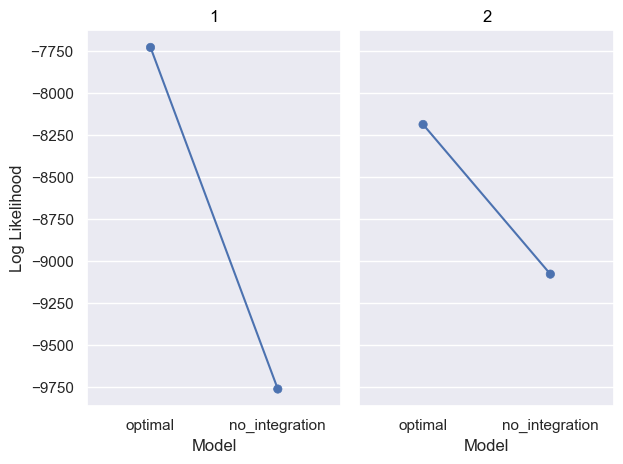

In [29]:
import seaborn.objects as so

g = (so.Plot(likelihood_df, x="model", y="log_likelihood")
    .add(so.Dot(), so.Agg("sum"),)
    .add(so.Lines(), so.Agg("sum"),)
    # .add(so.Lines(), so.Agg("sum"))
    .facet(col="vis_noise")
    .scale(color=so.Nominal())
    .label(x="Model", y="Log Likelihood")
)
g.show()

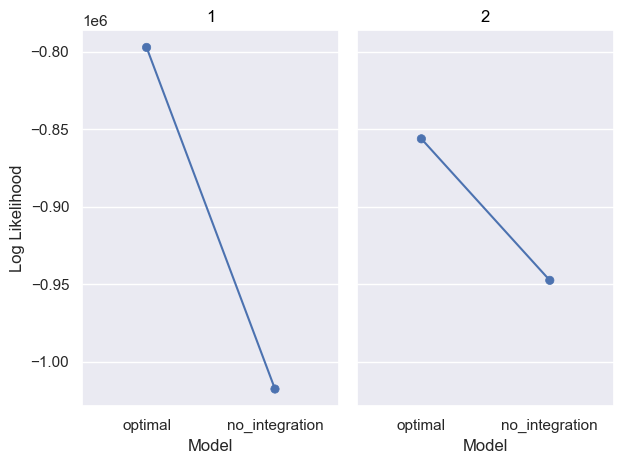

In [23]:
import seaborn.objects as so

g = (so.Plot(likelihood_df, x="model", y="log_likelihood")
    .add(so.Dot(), so.Agg("sum"),)
    .add(so.Lines(), so.Agg("sum"),)
    # .add(so.Lines(), so.Agg("sum"))
    .facet(col="vis_noise")
    .scale(color=so.Nominal())
    .label(x="Model", y="Log Likelihood")
)
g.show()

In [14]:
import numpy as np

model_classes = ["BoundedActorPointMassDynamics", "BoundedActor"]
df_sim = pd.concat(dfs, ignore_index=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]

In [15]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}

df_sim["integration"] = df_sim["model"].map(integration_name)
df_sim["dynamics"] = df_sim["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

In [16]:
mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "integration", "dynamics", "Visual target", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .mean()
    .reset_index()
)

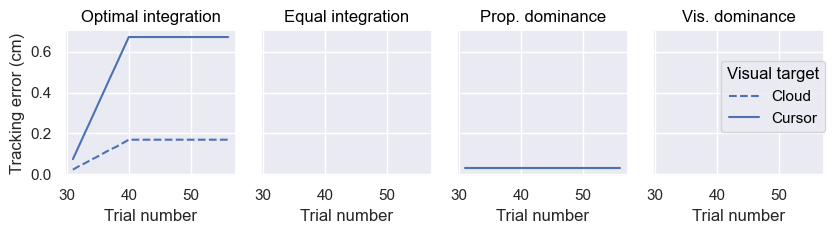

In [17]:
model_order = ["Optimal integration", "Equal integration", "Prop. dominance", "Vis. dominance"]

g = (
    so.Plot(
        mean_df[mean_df["dynamics"] == "Point mass"],
        x="trial_number",
        y="tracking_error",
        linestyle="Visual target",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Cursor": "-", "Cloud": "--"}))
    .facet(col="integration", order={"col": model_order})
    .layout(size=(8.5, 2.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.show()

In [8]:
import pandas as pd
import seaborn.objects as so

participants_to_exclude = [173058413, 330954011, 657093471]
# participants = [135033060, 177196795, 182095555, 212056115, 524048600, 544725341, 644801403, 657093471, 714671738, 741917610, 765738475, 799755310, 802096684, 879521247, 891444214, 910949717]
# participants = participants[:3]
df = load_multisensory_data(base_path="../data")
participants = df["participant"].unique()

# aggregate log likelihood csv files
likelihood_df = pd.concat(
    [
        pd.read_csv(
            f"../results/calibration/multisensory-simulations-calibration-likelihoods-{participant}_{prop_delay}_{vis_delay}_{seed}_{nwarmup}_{nsamp}_{nchain}_{model_class}_{conditions}.csv"
        )
        for participant in participants if participant not in participants_to_exclude
        for model_class in ["BoundedActorPointMassDynamics", "BoundedActor"]
    ]
)

likelihood_df

Multisensory DataFrame loaded from ../data/multisensory/data_all_downsampled.csv with shape: (540746, 12)


,participant,model,model_class,trial_number,vis_noise,log_likelihood
0,135033060,optimal,BoundedActorPointMassDynamics,31,1,-47183.664062
1,135033060,optimal,BoundedActorPointMassDynamics,31,2,-25612.777344
2,135033060,optimal,BoundedActorPointMassDynamics,32,1,-42170.496094
3,135033060,optimal,BoundedActorPointMassDynamics,32,2,-23990.695312
4,135033060,optimal,BoundedActorPointMassDynamics,33,1,-29128.478516
...,...,...,...,...,...,...
203,918338248,vision_only,BoundedActor,54,2,-136983.031250
204,918338248,vision_only,BoundedActor,55,1,-172209.562500
205,918338248,vision_only,BoundedActor,55,2,-141856.406250
206,918338248,vision_only,BoundedActor,56,1,-188483.500000


In [9]:
sum_likelihood_df = likelihood_df.groupby(["model", "model_class", "participant"]).agg({"log_likelihood": "sum"}).reset_index()
sum_likelihood_df

# compute difference with respect to the optimal model
optimal_likelihood_df = sum_likelihood_df[sum_likelihood_df["model"] == "optimal"]
sum_likelihood_df = sum_likelihood_df.merge(        
    optimal_likelihood_df[["model_class", "participant", "log_likelihood"]].rename(columns={"log_likelihood": "optimal_log_likelihood"}),
    on=["model_class", "participant"],
)
sum_likelihood_df["log_likelihood_diff"] = sum_likelihood_df["log_likelihood"] - sum_likelihood_df["optimal_log_likelihood"]

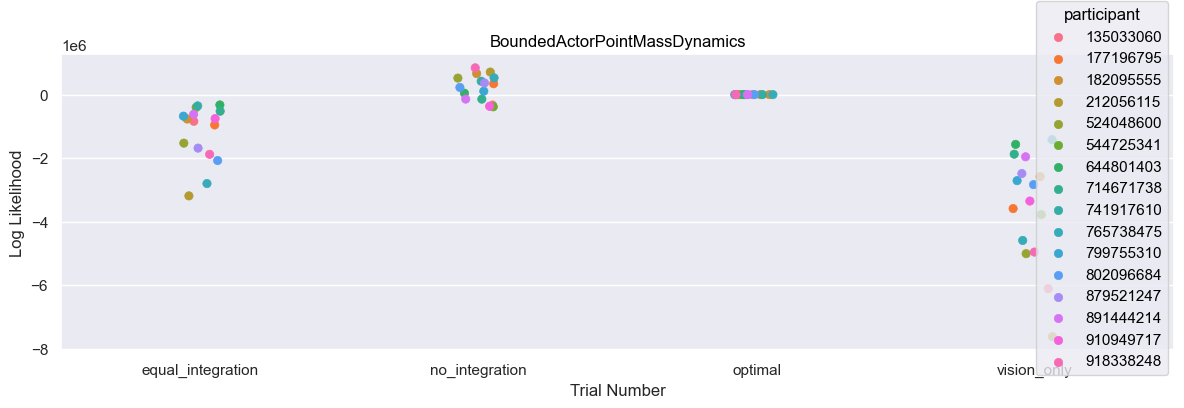

In [12]:
g = (so.Plot(sum_likelihood_df[sum_likelihood_df["model_class"] == "BoundedActorPointMassDynamics"], x="model", y="log_likelihood_diff", color="participant")
    .add(so.Dot(), so.Agg("sum"), so.Jitter())
    # .add(so.Lines(), so.Agg("sum"))
    # .add(so.Lines(), so.Agg("sum"))
    # .facet(col="participant")
    .scale(color=so.Nominal())
    .facet(col="model_class")
    .layout(size=(12, 4))
            .label(x="Trial Number", y="Log Likelihood")
)
g.show()

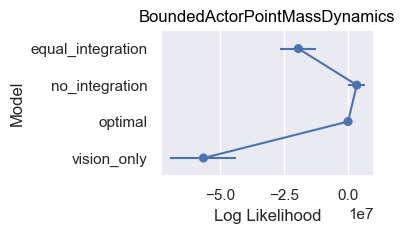

In [17]:
g = (
    so.Plot(
        sum_likelihood_df[
            sum_likelihood_df["model_class"] == "BoundedActorPointMassDynamics"
        ],
        y="model",
        x="log_likelihood_diff",
    )
    .add(so.Dot(), so.Agg("sum"))
    .add(so.Lines(), so.Agg("sum"))
    .add(so.Range(), so.Est(func="sum", errorbar="ci"))
    # .add(so.Lines(), so.Agg("sum"))
    # .facet(col="participant")
    .scale(color=so.Nominal())
    .facet(col="model_class")
    .layout(size=(4.0, 2.5))
    .label(y="Model", x="Log Likelihood")
)
g.show()

In [ ]:
# get the best-fitting model per participant
best_per_participant = (
    sum_likelihood_df.loc[sum_likelihood_df.groupby("participant")["log_likelihood"].idxmax(), ["model", "model_class", "participant"]]
)

win_counts = (
    best_per_participant["model"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["integration", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="integration", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal())
    .label(x="", y="Number of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

In [9]:
import numpy as np

model_classes = ["BoundedActorPointMassDynamics", "BoundedActor"]
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv") for p in participants for model_class in model_classes]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]

In [10]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}

df_sim["integration"] = df_sim["model"].map(integration_name)
df_sim["dynamics"] = df_sim["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

In [11]:
mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "integration", "dynamics", "Visual target", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)

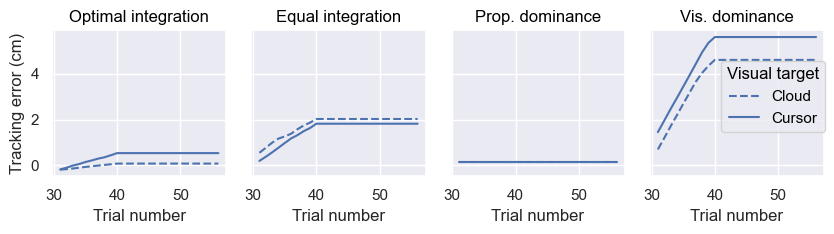

In [12]:
model_order = ["Optimal integration", "Equal integration", "Prop. dominance", "Vis. dominance"]

g = (
    so.Plot(
        mean_df[mean_df["dynamics"] == "Point mass"],
        x="trial_number",
        y="tracking_error",
        linestyle="Visual target",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Cursor": "-", "Cloud": "--"}))
    .facet(col="integration", order={"col": model_order})
    .layout(size=(8.5, 2.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.save("../figures/predictions_offset.svg")
g.show()